In [1]:

# Notebook  : Réseaux de Neurones Convolutionnels (CNN) pour la Classification d’Images

import numpy as np
import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import applications # type: ignore
from tensorflow.keras import layers # type: ignore
import matplotlib.pyplot as plt

# Charger le dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalisation des images
x_train, x_test = x_train / 255.0, x_test / 255.0

# Définition du modèle CNN
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25), #Ajout
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25), #Ajout
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), #Ajout
    layers.Dropout(0.5), #Ajout
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
history_fit = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test))

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')


# Question pour expérimenter l'Apprentissage par Transfert

# Charger le modèle pré-entraîné  VGG16
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Geler les poids du modèle pré-entraîné

# Ajouter une couche de classification personnalisée
transfer_model = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation et entraînement du modèle avec transfert d’apprentissage
transfer_model.compile(optimizer='sgd',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Entraînement rapide pour test
transfer_model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test))

# Comparer la performance avec et sans transfert d’apprentissage
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(x_test, y_test, verbose=2)
print(f'Précision avec apprentissage par transfert : {test_acc_transfer:.4f}')


Epoch 1/20
1563/1563 [==============================] - 35s 22ms/step - loss: 1.6805 - accuracy: 0.3819 - val_loss: 1.3146 - val_accuracy: 0.5204
Epoch 2/20
1563/1563 [==============================] - 36s 23ms/step - loss: 1.3707 - accuracy: 0.5083 - val_loss: 1.2268 - val_accuracy: 0.5727
Epoch 3/20
1563/1563 [==============================] - 35s 23ms/step - loss: 1.2381 - accuracy: 0.5618 - val_loss: 1.1062 - val_accuracy: 0.6029
Epoch 4/20
1563/1563 [==============================] - 35s 22ms/step - loss: 1.1620 - accuracy: 0.5927 - val_loss: 1.0238 - val_accuracy: 0.6366
Epoch 5/20
1563/1563 [==============================] - 35s 23ms/step - loss: 1.0960 - accuracy: 0.6182 - val_loss: 0.9942 - val_accuracy: 0.6503
Epoch 6/20
1563/1563 [==============================] - 36s 23ms/step - loss: 1.0527 - accuracy: 0.6354 - val_loss: 0.9633 - val_accuracy: 0.6623
Epoch 7/20
1563/1563 [==============================] - 38s 24ms/step - loss: 1.0172 - accuracy: 0.6478 - val_loss: 0.9257 -

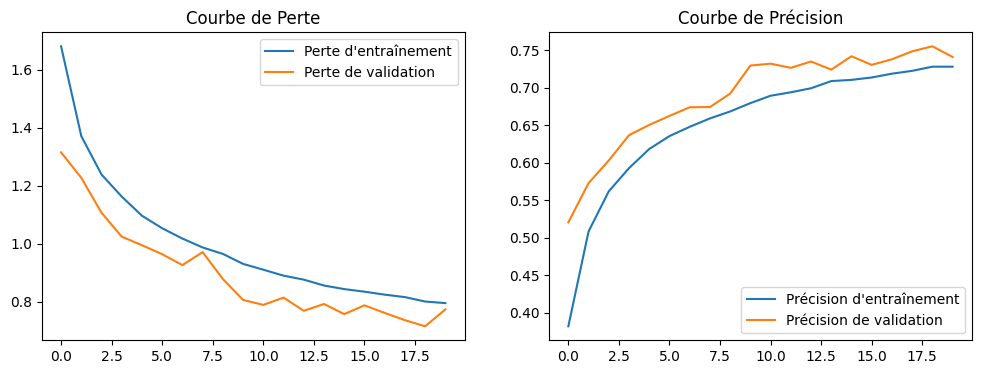

In [2]:
# Afficher les courbes d'apprentissage (perte et précision)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fit.history['loss'], label='Perte d\'entraînement')
plt.plot(history_fit.history['val_loss'], label='Perte de validation')
plt.legend()
plt.title('Courbe de Perte')

plt.subplot(1, 2, 2)
plt.plot(history_fit.history['accuracy'], label='Précision d\'entraînement')
plt.plot(history_fit.history['val_accuracy'], label='Précision de validation')
plt.legend()
plt.title('Courbe de Précision')

plt.show()

In [3]:
# Définir les classes
CLASSES = np.array([
    "avion",
    "voiture",
    "oiseau",
    "chat",
    "cerf",
    "chien",
    "grenouille",
    "cheval",
    "bateau",
    "camion",
])

# Prédire les classes pour les données de test
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Flatten y_test (important)
y_true = y_test.flatten()


313/313 [==============================] - 2s 6ms/step


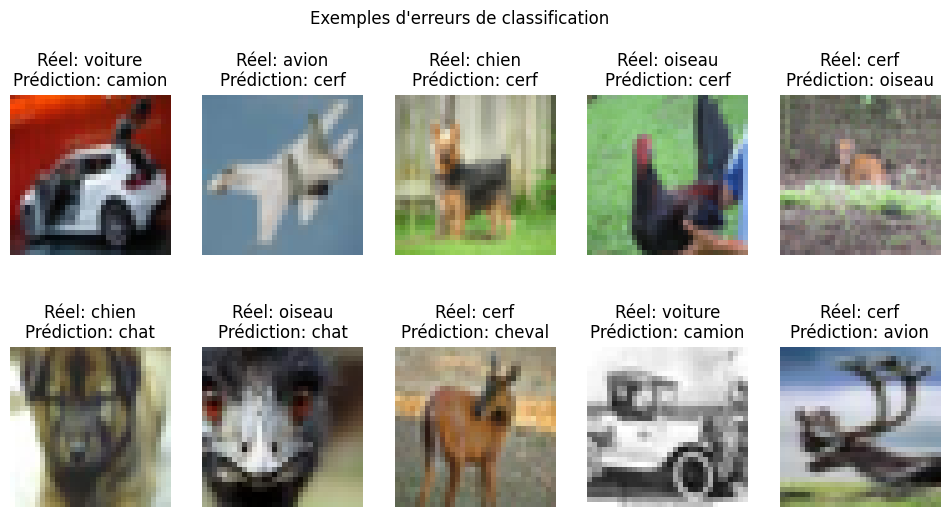

In [4]:
# Indices des erreurs
errors = np.where(y_pred != y_true)[0]

# Afficher 10 erreurs
plt.figure(figsize=(12, 6))

for i, idx in enumerate(errors[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx])
    plt.title(f"Réel: {CLASSES[y_true[idx]]}\nPrédiction: {CLASSES[y_pred[idx]]}")
    plt.axis('off')

plt.suptitle("Exemples d'erreurs de classification")
plt.show()